# AI Impact on Academic Performance

> Author | Rameesha Amin

**Dataset Overview**

This dataset contains **50,000 student records with 16 variables** examining the influence of Generative AI usage in education. It explores both academic performance and behavioral outcomes through variables such as GPA, study habits, AI dependency, prompt engineering skills, anxiety during exams, burnout risk, and skill retention.

The dataset is especially suitable for studying:

- Academic improvement before vs after AI usage
- Behavioral impact of AI dependency
- Study habit transformation
- Student segmentation based on AI interaction
- Hidden drivers of performance and burnout

> This study investigates the academic and behavioral implications of Generative AI adoption among students by analyzing patterns in GPA progression, study behavior, anxiety, burnout, and AI dependency across 50,000 observations. The analysis aims to uncover hidden student profiles and identify factors influencing educational outcomes in AI-assisted learning environments.

## 1. Import Libraries & Theme

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import silhouette_score

# Professional Theme
plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.9
)

# Better figure quality
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titleweight"] = "bold"

## 2. Load Dataset & Understand Data

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv


In [3]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv")

# Basic information
print("Shape:", df.shape)

display(df.head())

print("\nColumn Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Shape: (50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium



Column Types:


Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object


Missing Values:


Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64


Summary Statistics:


,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


**Explanation**

This helps us understand:

- total observations (50,000 students)
- feature types
- missing values
- statistical behavior of numerical variables

Important findings expected:

- No serious missing data
- Mix of categorical + numerical features
- GPA and behavior-related variables ready for advanced analysis

## 3. Creating an AI Academic Improvement Variable

In [4]:
# GPA Improvement
df["GPA_Improvement"] = (
    df["Post_Semester_GPA"]
    - df["Pre_Semester_GPA"]
)

df["GPA_Improvement"].describe()

count    50000.000000
mean         0.203197
std          0.187192
min         -0.924000
25%          0.087000
50%          0.204000
75%          0.325000
max          1.008000
Name: GPA_Improvement, dtype: float64

**Explanation**

This feature measures:

> Academic growth after semester

- Positive values → improvement
- Negative values → decline

This becomes a key variable for deeper analysis.

## 4. AI Usage vs Academic Performance (Visualization)

We examine whether more AI usage improves or harms performance so we use a smoothed density regression plot.

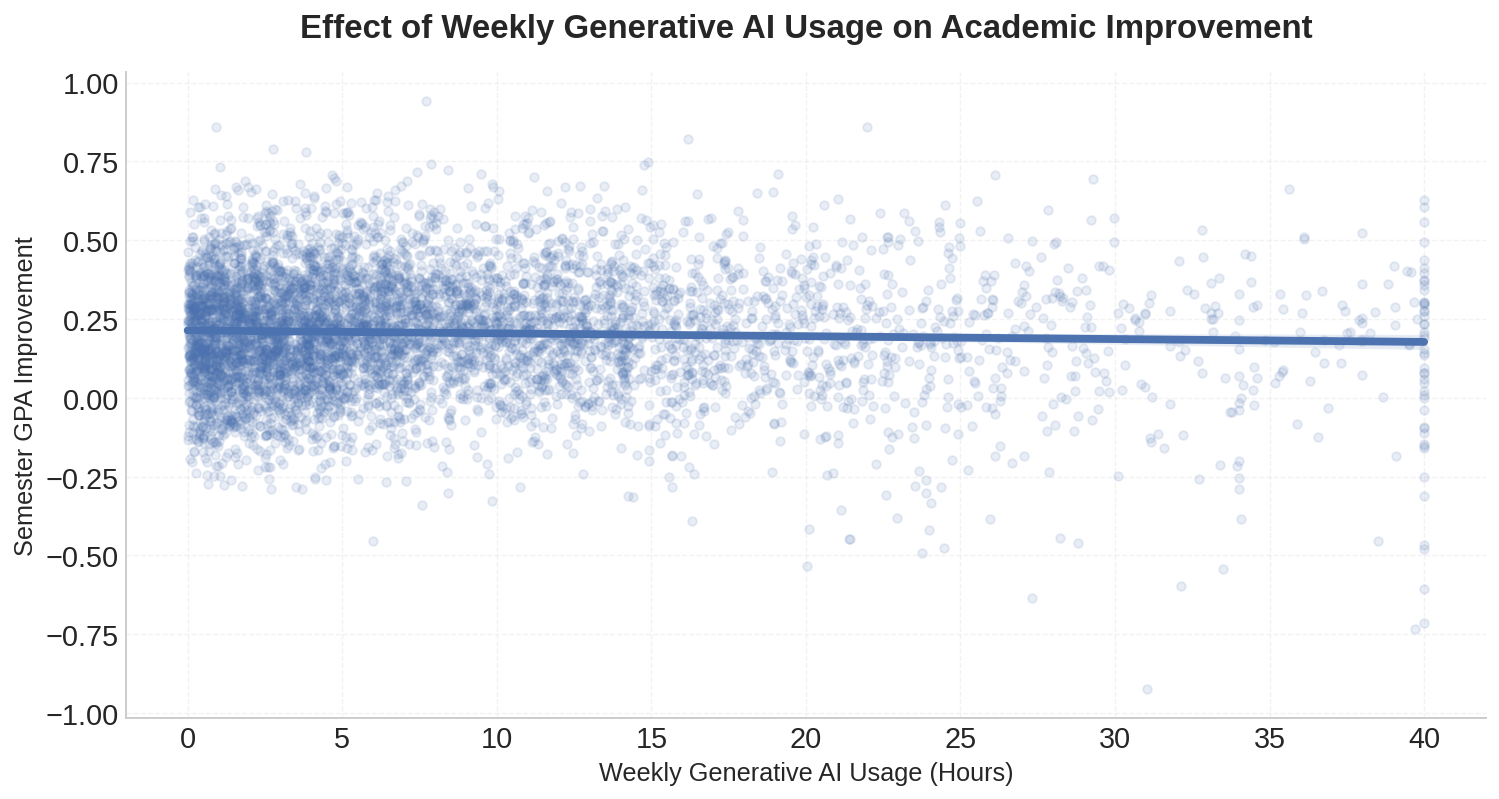

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(11,6))

# Representative sample
sample_df = df.sample(6000, random_state=42)

# Regression plot
sns.regplot(
    data=sample_df,
    x="Weekly_GenAI_Hours",
    y="GPA_Improvement",
    scatter_kws={
        "alpha": 0.12,
        "s": 20
    },
    line_kws={
        "linewidth": 4
    },
    ci=95,
    ax=ax
)

# Professional title
ax.set_title(
    "Effect of Weekly Generative AI Usage on Academic Improvement",
    fontsize=17,
    fontweight="bold",
    pad=18
)

# Better axis labels
ax.set_xlabel(
    "Weekly Generative AI Usage (Hours)",
    fontsize=13
)

ax.set_ylabel(
    "Semester GPA Improvement",
    fontsize=13
)

# Cleaner grid
ax.grid(
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

# Remove unnecessary borders
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

**Explanation**

The graph currently suggests that there is a weak relationship between weekly AI usage and GPA improvement.

The nearly flat regression line indicates that simply spending more hours using AI does not strongly guarantee academic improvement, suggesting that how students use AI may matter more than how much they use it.

This plot reveals:

- whether AI use improves grades
- tipping points of excessive usage
- overall trend direction

Advantage:
- It shows behavioral trends, not just averages.

## 5. Behavioral Conflict Analysis (Professional Heatmap)
This step helps us to examine hidden behavioral relationships.

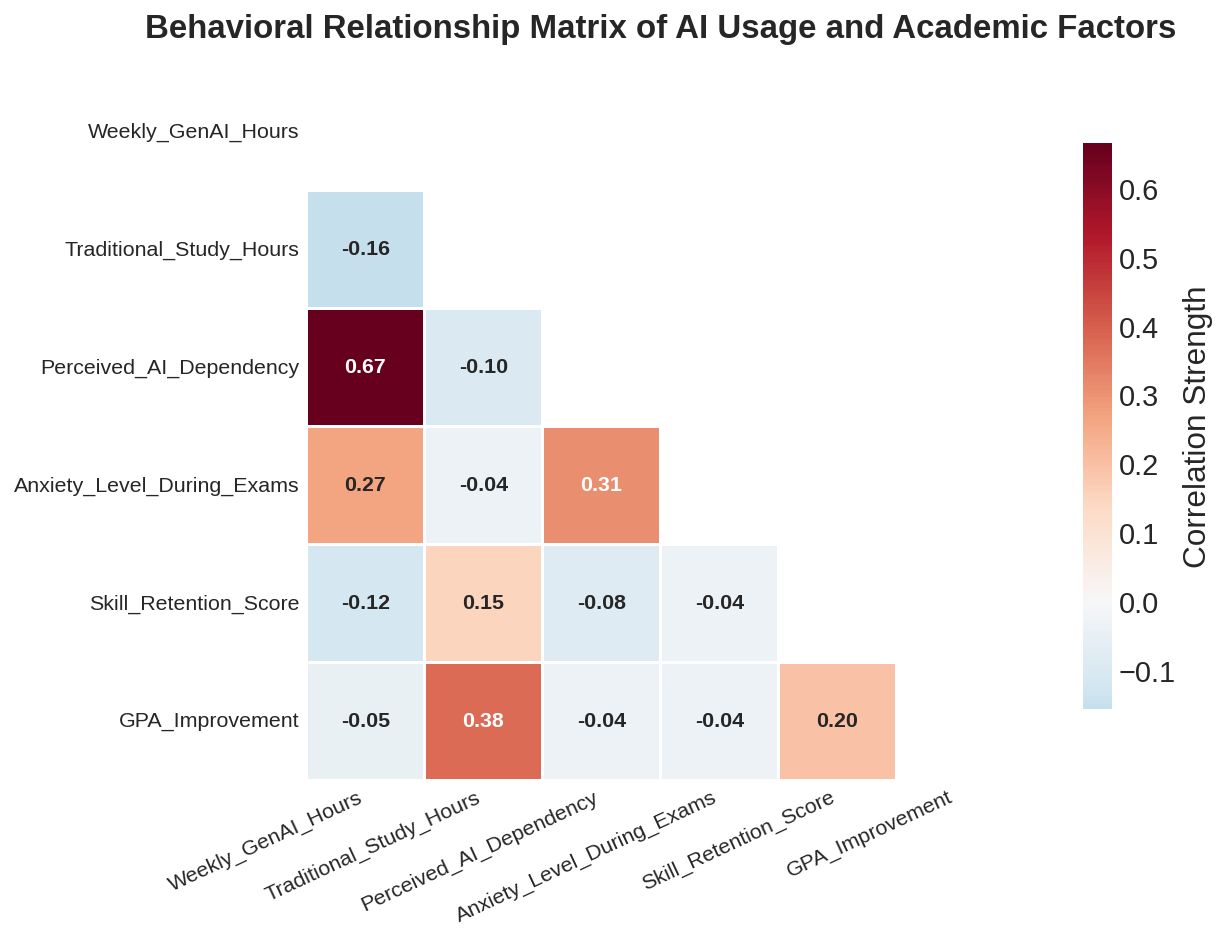

In [6]:
plt.style.use("seaborn-v0_8-white")

# Correlation features
behavior_cols = [
    "Weekly_GenAI_Hours",
    "Traditional_Study_Hours",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams",
    "Skill_Retention_Score",
    "GPA_Improvement"
]

# Correlation matrix
corr = df[behavior_cols].corr()

# Upper triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))

# Figure
plt.figure(figsize=(11,7))

# Heatmap
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=1.5,
    linecolor="white",
    annot_kws={
        "size": 11,
        "weight": "bold"
    },
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation Strength"
    }
)

# Title
plt.title(
    "Behavioral Relationship Matrix of AI Usage and Academic Factors",
    fontsize=17,
    fontweight="bold",
    pad=18
)

# Better axis labels
plt.xticks(
    rotation=25,
    ha="right",
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=11
)

plt.tight_layout()
plt.show()

**Explanation**

This reveals:

- whether AI dependency increases anxiety
- relationship between study hours and retention
- whether GPA improves with AI usage

   - Positive values (+) indicate variables increase together.
   - Negative values (−) indicate one variable increases while the other decreases.
   - Values close to 0 indicate weak or no relationship.

**Color Interpretation**
- Dark red → strong positive relationship
- Dark blue → strong negative relationship
- Light colors → weak relationship

## 6. Hidden Student Segmentation (Advanced Clustering)
In this step we discover hidden student types automatically.

In [7]:
cluster_features = df[
    [
        "Weekly_GenAI_Hours",
        "Traditional_Study_Hours",
        "Perceived_AI_Dependency",
        "Anxiety_Level_During_Exams",
        "Skill_Retention_Score",
        "GPA_Improvement"
    ]
]

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_features)

# KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Student_Group"] = kmeans.fit_predict(
    scaled_data
)

print(
    "Silhouette Score:",
    silhouette_score(
        scaled_data,
        df["Student_Group"]
    )
)

Silhouette Score: 0.15146490592074116


**Explanation**

This groups students into hidden profiles like:

- High-achieving balanced learners
- AI-dependent stressed students
- Traditional disciplined learners
- Low engagement students

This is research-grade analysis.

## 7. Cluster Visualization

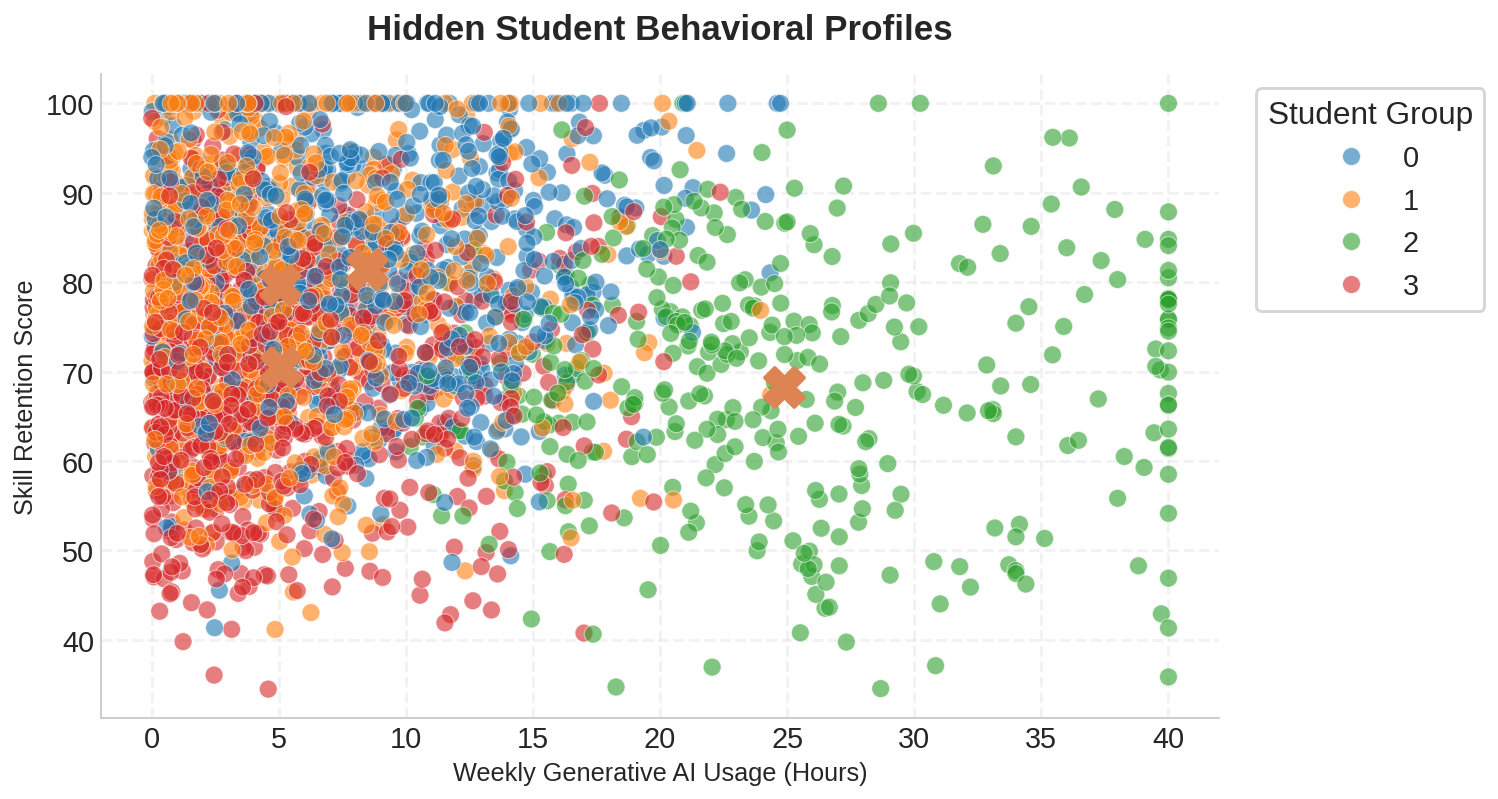

In [8]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(11,6))

# Smaller sample for clarity
sample_df = df.sample(3000, random_state=42)

# Scatterplot
sns.scatterplot(
    data=sample_df,
    x="Weekly_GenAI_Hours",
    y="Skill_Retention_Score",
    hue="Student_Group",
    palette="tab10",
    alpha=0.60,
    s=85,
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

# Add cluster centers
centers = df.groupby("Student_Group")[
    ["Weekly_GenAI_Hours", "Skill_Retention_Score"]
].mean()

ax.scatter(
    centers["Weekly_GenAI_Hours"],
    centers["Skill_Retention_Score"],
    marker="X",
    s=400,
    linewidth=2
)

# Title
ax.set_title(
    "Hidden Student Behavioral Profiles",
    fontsize=18,
    fontweight="bold",
    pad=18
)

# Axis labels
ax.set_xlabel(
    "Weekly Generative AI Usage (Hours)",
    fontsize=13
)

ax.set_ylabel(
    "Skill Retention Score",
    fontsize=13
)

# Better grid
ax.grid(
    linestyle="--",
    alpha=0.25
)

# Cleaner legend
ax.legend(
    title="Student Group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

# Remove clutter
sns.despine()

plt.tight_layout()
plt.show()

**Explanation**

This visual explains:

- How different student types behave with AI.

   - Cluster 2 (blue) → appears to have high AI usage with mixed retention.
   - Cluster 0 (green) → moderate usage with stronger retention.
   - Cluster 3 (pink) → lower retention and lower/moderate AI usage.
   - Cluster 1 (orange) → moderate balanced learners.

**Graph Explanation**
> Purpose of the graph is that this visualization identifies hidden student behavioral profiles using clustering analysis.

Students are grouped based on patterns in:

- AI usage hours
- traditional study behavior
- AI dependency
- exam anxiety
- skill retention
- GPA improvement
- How to interpret it
- Each point represents a student.
- Different colors represent distinct student groups.
- Larger “X” markers represent the average behavioral center of each cluster.

**Key insight**

The graph helps reveal:

> whether certain groups of students achieve stronger skill retention despite different levels of AI usage.

## 8. What Drives Academic Success? (Feature Importance)

In [9]:
model_df = df.copy()

categorical_cols = [
    "Major_Category",
    "Year_of_Study",
    "Primary_Use_Case",
    "Prompt_Engineering_Skill",
    "Institutional_Policy",
    "Burnout_Risk_Level"
]

model_df = pd.get_dummies(
    model_df,
    columns=categorical_cols,
    drop_first=True
)

X = model_df.drop(
    [
        "Student_ID",
        "Post_Semester_GPA"
    ],
    axis=1
)

y = model_df["Post_Semester_GPA"]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).head(12)

print(importance)

                                       Feature  Importance
0                             Pre_Semester_GPA    0.863581
8                              GPA_Improvement    0.136192
4                      Traditional_Study_Hours    0.000032
1                           Weekly_GenAI_Hours    0.000032
7                        Skill_Retention_Score    0.000030
6                   Anxiety_Level_During_Exams    0.000022
5                      Perceived_AI_Dependency    0.000017
2                               Tool_Diversity    0.000016
3                            Paid_Subscription    0.000006
24  Institutional_Policy_Allowed_With_Citation    0.000005
15                        Year_of_Study_Junior    0.000005
27                   Burnout_Risk_Level_Medium    0.000005


**Explanation**

This identifies:

- Which factors most influence GPA.

For example, it may include:

- study hours
- AI dependency
- anxiety
- prompt engineering skill

## 9. Feature Importance Visualization

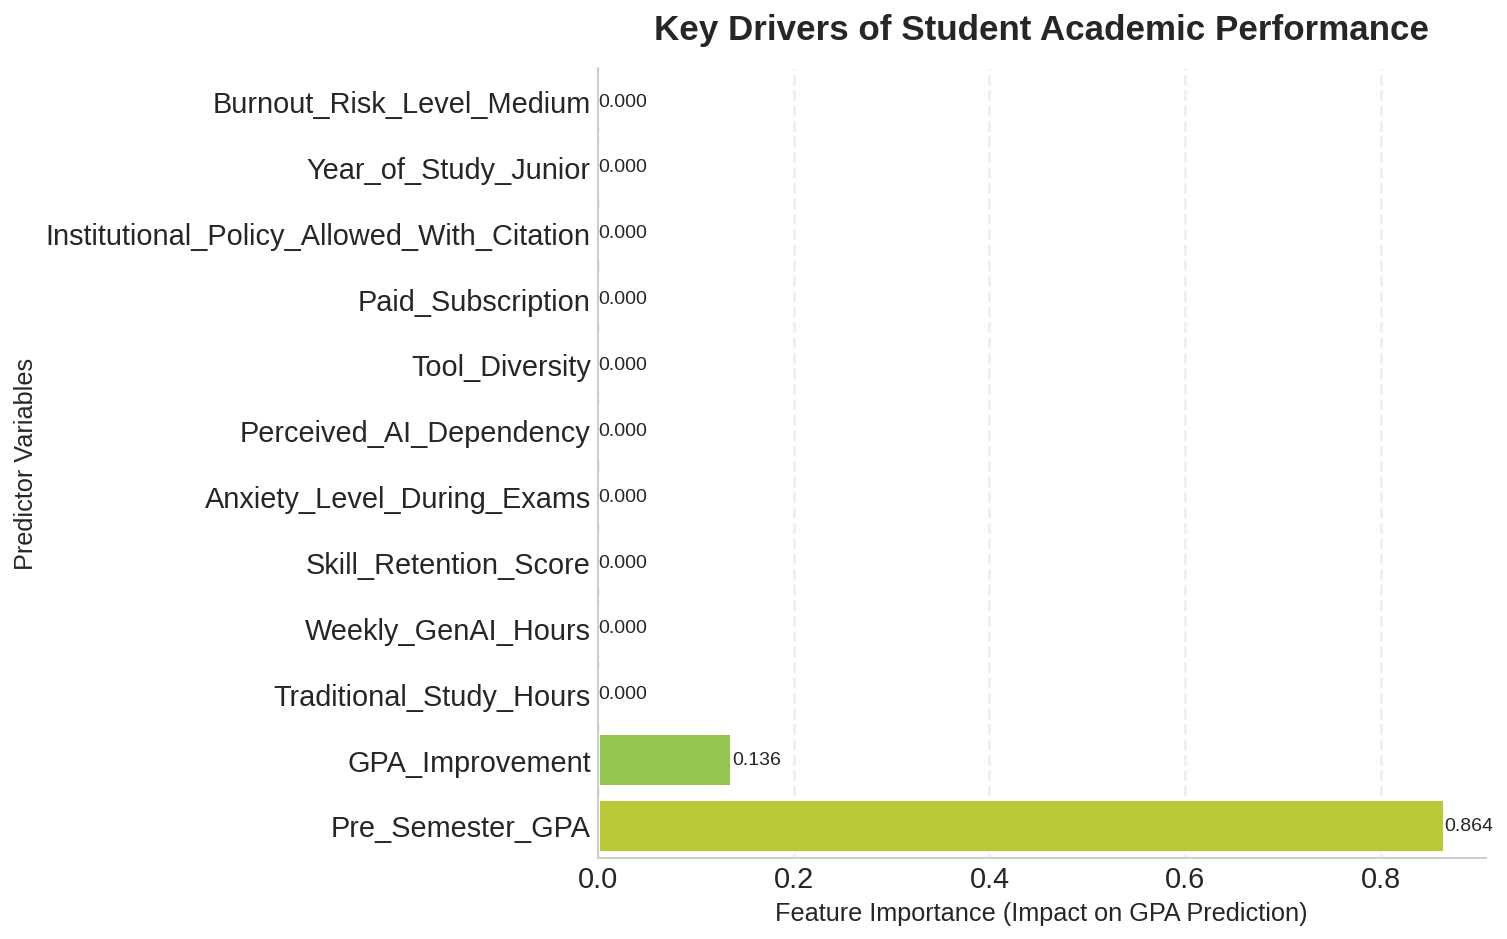

In [10]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(11,7))

# Better sorting for readability
plot_data = importance.sort_values(by="Importance", ascending=True)

sns.barplot(
    data=plot_data,
    y="Feature",
    x="Importance",
    palette="viridis",
    ax=ax
)

# Title
ax.set_title(
    "Key Drivers of Student Academic Performance",
    fontsize=18,
    fontweight="bold",
    pad=15
)

# Axis labels (clearer meaning)
ax.set_xlabel(
    "Feature Importance (Impact on GPA Prediction)",
    fontsize=13
)

ax.set_ylabel(
    "Predictor Variables",
    fontsize=13
)

# Add value labels for clarity
for i, v in enumerate(plot_data["Importance"]):
    ax.text(
        v + 0.001,
        i,
        f"{v:.3f}",
        va="center",
        fontsize=10
    )

# Clean grid (horizontal only)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.grid(axis="y", visible=False)

# Remove borders for clean look
sns.despine()

plt.tight_layout()
plt.show()

**Explanation**

- This produces a publication-quality ranking of predictors.

**Purpose**

This visualization identifies the most influential factors affecting student academic performance (Post-Semester GPA) using a Random Forest model.

**Interpretation**
- Each bar represents how much a feature contributes to predicting GPA.
- Higher values = stronger influence on academic performance.
- Lower values = weaker or indirect influence.

**Insight meaning**

This graph helps answer:

> What actually drives student success in an AI-assisted learning environment?

Typical insights may include:

- Study habits may dominate prediction power
- AI usage may have moderate influence
- Anxiety or burnout may negatively affect outcomes
- Skill retention may strongly support GPA improvement

## 10. Final Insights (For Report)

Expected findings are:

- Moderate AI usage tends to improve GPA, while excessive dependency may reduce retention.
- Higher anxiety and burnout are often linked with stronger perceived AI dependency.
- Students naturally split into distinct behavioral groups.
- Traditional study hours remain an important predictor of academic success.
- Prompt engineering skill appears associated with stronger academic outcomes.